In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from Utilities.CoordinateManager import CoordinateManager

# Scaling factor of 4x
lr_shape = (8, 8)     # Low resolution
hr_shape = (32, 32)   # High resolution

# Generate coordinates
lr_coords = CoordinateManager.CreateCoordinates(lr_shape)
hr_coords = CoordinateManager.CreateCoordinates(hr_shape)

# Convert to numpy
lr_coords = lr_coords.numpy()
hr_coords = hr_coords.numpy()

#### Side by side generated coordinates

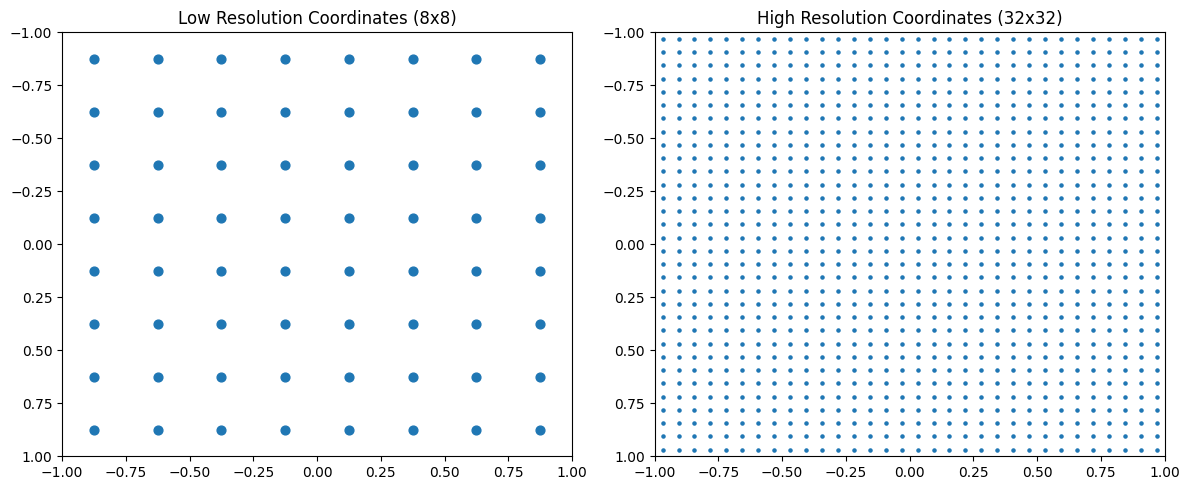

In [2]:
plt.figure(figsize=(12, 5))

# Common ticks
ticks = np.linspace(-1, 1, 9) 

# --- LR plot ---
plt.subplot(1, 2, 1)
plt.scatter(lr_coords[:, 1], lr_coords[:, 0], s=40)
plt.title("Low Resolution Coordinates (8x8)")
plt.xlim(-1, 1)
plt.ylim(1, -1) 
plt.xticks(ticks)
plt.yticks(ticks)

# --- HR plot ---
plt.subplot(1, 2, 2)
plt.scatter(hr_coords[:, 1], hr_coords[:, 0], s=5)
plt.title("High Resolution Coordinates (32x32)")
plt.xlim(-1, 1)
plt.ylim(1, -1)  
plt.xticks(ticks)
plt.yticks(ticks)

plt.tight_layout()
plt.show()

##### Overlayed the 2 coordinate systems

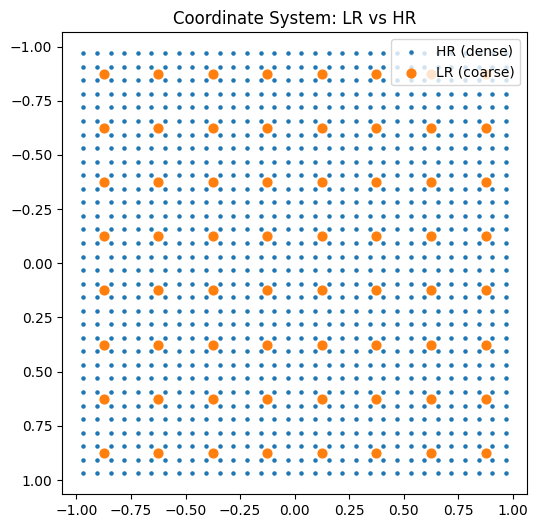

In [3]:
plt.figure(figsize=(6, 6))

plt.scatter(hr_coords[:, 1], hr_coords[:, 0], s=5, label="HR (dense)")
plt.scatter(lr_coords[:, 1], lr_coords[:, 0], s=40, label="LR (coarse)")

plt.title("Coordinate System: LR vs HR")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

### Coordiante axis and grid as RGB pixels

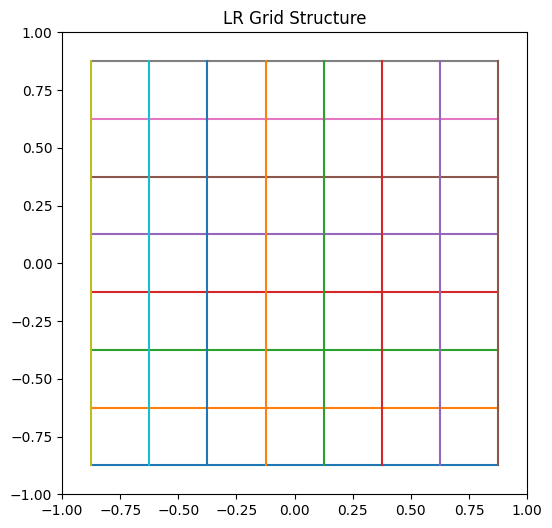

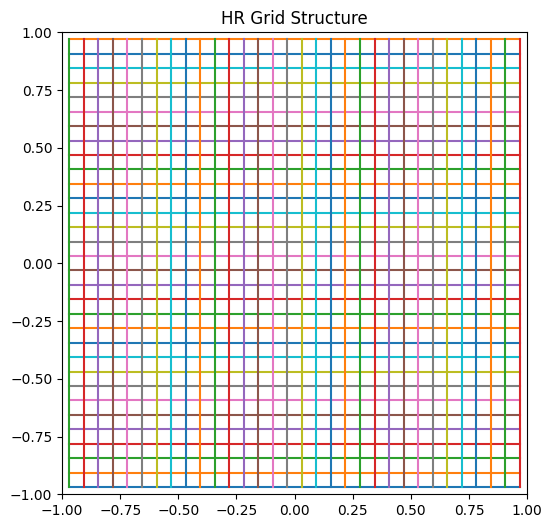

In [4]:
def plot_grid(coords, shape, title):
    coords = coords.reshape(shape[0], shape[1], 2)

    ticks = np.linspace(-1, 1, 9)

    plt.figure(figsize=(6, 6))

    # Draw horizontal lines
    for i in range(shape[0]):
        plt.plot(coords[i, :, 1], coords[i, :, 0], '-')

    # Draw vertical lines
    for j in range(shape[1]):
        plt.plot(coords[:, j, 1], coords[:, j, 0], '-')

    plt.xlim(-1, 1)
    plt.ylim(1, -1) 
    plt.xticks(ticks)
    plt.yticks(ticks)

    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()


plot_grid(CoordinateManager.CreateCoordinates(lr_shape, flatten=False).numpy(),
          lr_shape,
          "LR Grid Structure")

plot_grid(CoordinateManager.CreateCoordinates(hr_shape, flatten=False).numpy(),
          hr_shape,
          "HR Grid Structure")



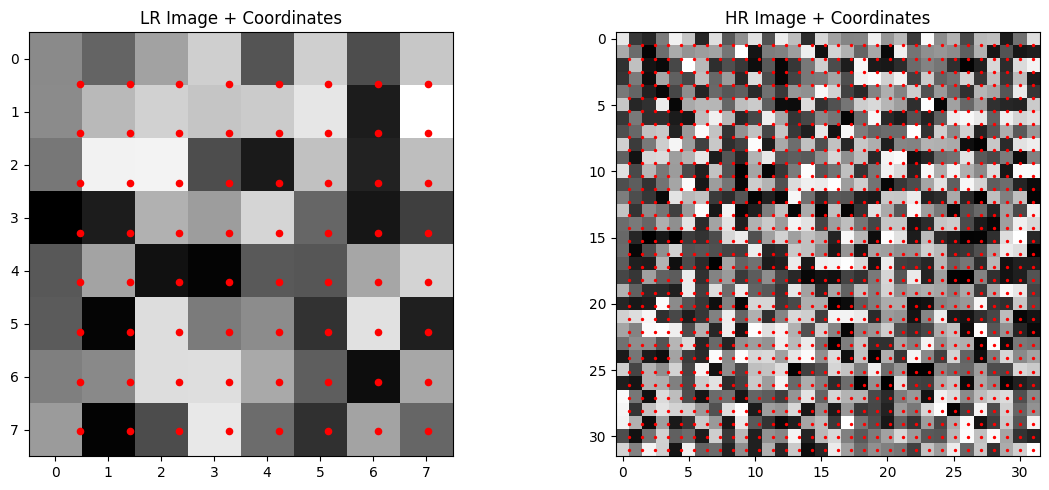

In [5]:
lr_img = np.random.rand(*lr_shape)
hr_img = np.random.rand(*hr_shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(lr_img, cmap='gray')
plt.scatter(
    (lr_coords[:, 1] + 1) / 2 * (lr_shape[1] - 0.5),
    (lr_coords[:, 0] + 1) / 2 * (lr_shape[0] - 0.5),
    s=20, c='red'
)
plt.title("LR Image + Coordinates")

plt.subplot(1, 2, 2)
plt.imshow(hr_img, cmap='gray')
plt.scatter(
    (hr_coords[:, 1] + 1) / 2 * (hr_shape[1] - 0.5),
    (hr_coords[:, 0] + 1) / 2 * (hr_shape[0] - 0.5),
    s=2, c='red'
)
plt.title("HR Image + Coordinates")

plt.tight_layout()
plt.show()

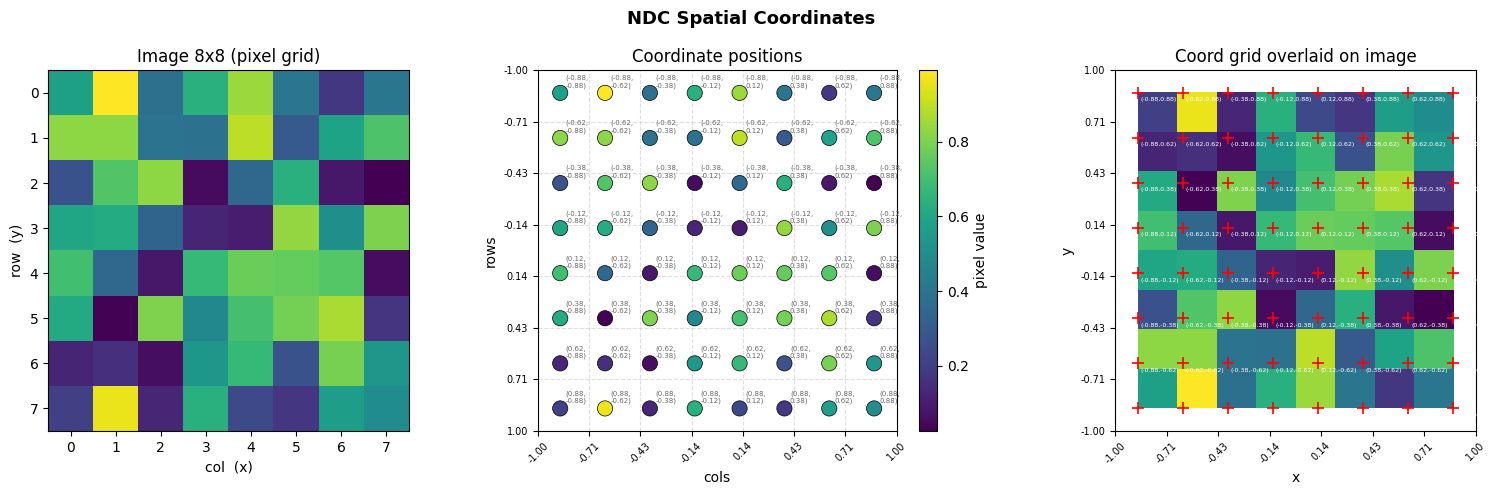

In [9]:
def visualize_coordinates(shape=(8, 8), ranges=None):
    image = torch.rand(*shape)
    coords_flat = CoordinateManager.CreateCoordinates(shape, ranges, flatten=True)
    coords_grid = CoordinateManager.CreateCoordinates(shape, ranges, flatten=False)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"NDC Spatial Coordinates", fontsize=13, fontweight="bold")

    tick_vals = np.linspace(-1, 1, shape[1]) 

    # raw pixel image
    ax = axes[0]
    ax.imshow(image.numpy(), cmap="viridis", origin="upper")
    ax.set_title("Image 8x8 (pixel grid)")
    ax.set_xlabel("col  (x)");  ax.set_ylabel("row  (y)")
    ax.set_xticks(range(shape[1]));  ax.set_yticks(range(shape[0]))

    # coordinates NDC
    ax = axes[1]
    cx = coords_flat[:, 1].numpy()
    cy = coords_flat[:, 0].numpy()
    pixel_vals = image.flatten().numpy()

    sc = ax.scatter(cx, cy, c=pixel_vals, cmap="viridis",
                    s=120, edgecolors="black", linewidths=0.5, zorder=3)
    fig.colorbar(sc, ax=ax, label="pixel value")

    for idx, (x, y, v) in enumerate(zip(cx, cy, pixel_vals)):
        row, col = divmod(idx, shape[1])
        ax.annotate(f"({coords_grid[row,col,0]:.2f},\n{coords_grid[row,col,1]:.2f})",
                    (x, y), textcoords="offset points", xytext=(4, 4),
                    fontsize=5, color="dimgray")

    ax.set_title("Coordinate positions")
    ax.set_xlabel("cols");  ax.set_ylabel("rows")
    ax.set_xlim(-1, 1);  ax.set_ylim(-1, 1)                 
    ax.set_xticks(tick_vals);  ax.set_yticks(tick_vals)      
    ax.set_xticklabels([f"{v:.2f}" for v in tick_vals], rotation=45, fontsize=7)
    ax.set_yticklabels([f"{v:.2f}" for v in tick_vals], fontsize=7)
    ax.invert_yaxis()
    ax.grid(True, linestyle="--", alpha=0.4)

    # grid overlay on image
    ax = axes[2]
    ax.imshow(image.numpy(), cmap="viridis", origin="upper",
              extent=[cx.min(), cx.max(), cy.max(), cy.min()])

    for row in range(shape[0]):
        for col in range(shape[1]):
            x = coords_grid[row, col, 1].item()
            y = coords_grid[row, col, 0].item()
            ax.plot(x, y, "r+", markersize=8, markeredgewidth=1.2)
            ax.annotate(f"({x:.2f},{y:.2f})", (x, y),
                        textcoords="offset points", xytext=(2, -6),
                        fontsize=4.5, color="white")

    ax.set_title("Coord grid overlaid on image")
    ax.set_xlabel("x");  ax.set_ylabel("y")
    ax.set_xlim(-1, 1);  ax.set_ylim(-1, 1)                 
    ax.set_xticks(tick_vals);  ax.set_yticks(tick_vals)      
    ax.set_xticklabels([f"{v:.2f}" for v in tick_vals], rotation=45, fontsize=7)
    ax.set_yticklabels([f"{v:.2f}" for v in tick_vals], fontsize=7)

    plt.tight_layout()
    plt.show()


visualize_coordinates(shape=(8, 8))